<a href="https://colab.research.google.com/github/MayaLakshmanaprabu/Maya-Priyadharshini-Lakshmanaprabu/blob/main/Copy_of_L8_Introduction_to_Python_Homework_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

# **Apartment cost and sizes in Germany**

**Where is the data from?**

The data was scraped from Immoscout24, the biggest real estate platform in Germany. Immoscout24 has listings for both rental properties and homes for sale, however, the data only contains offers for rental properties.
The scraping process is described in this blog post and the corresponding code for scraping and minimal processing afterwards can be found in this Github repo.
At a given time, all available offers were scraped from the site and saved. This process was repeated three times, so the data set contains offers from the dates 2018-09-22, 2019-05-10 and 2019-10-08.

**Content**

The data set contains most of the important properties, such as living area size, the rent, both base rent as well as total rent (if applicable), the location (street and house number, if available, ZIP code and state), type of energy etc. It also has two variables containing longer free text descriptions: description with a text describing the offer and facilities describing all available facilities, newest renovation etc. The date column was added to give the time of scraping.

**Inspiration**

Did rents increase over time? Which areas are the most expensive? Which areas saw the largest increase, which areas became cheaper? Are there any duplicates? How many? What could be gained from a text analysis of the free text variables?

**Acknowledgements**

The data belongs to www.immobilienscount24.de and is for research purposes only. The data was created with .


**Here you can find the data -->**

https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany


In [ ]:
import pandas as pd
import numpy as np
df =pd.read_csv("/content/immo_data 2.csv")

In [39]:
df.head()

,regio1,serviceCharge,heatingType,telekomTvOffer,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,totalRent,...,floor,numberOfFloors,noRoomsRange,garden,livingSpaceRange,regio2,regio3,description,facilities,date
0,Nordrhein_Westfalen,245.00,central_heating,ONE_YEAR_FREE,False,False,6,4.62,10.0,840.0,...,1.0,3.0,4,True,4,Dortmund,Schüren,Die ebenerdig zu erreichende Erdgeschosswohnun...,Die Wohnung ist mit Laminat ausgelegt. Das Bad...,May19
1,Rheinland_Pfalz,134.00,self_contained_central_heating,ONE_YEAR_FREE,False,True,8,3.47,10.0,NaN,...,NaN,NaN,3,False,4,Rhein_Pfalz_Kreis,Böhl_Iggelheim,Alles neu macht der Mai – so kann es auch für ...,NaN,May19
2,Sachsen,255.00,floor_heating,ONE_YEAR_FREE,True,True,8,2.72,2.4,1300.0,...,3.0,4.0,3,False,4,Dresden,Äußere_Neustadt_Antonstadt,Der Neubau entsteht im Herzen der Dresdner Neu...,"* 9 m² Balkon\n* Bad mit bodengleicher Dusche,...",Oct19
3,Sachsen,58.15,district_heating,ONE_YEAR_FREE,False,True,9,1.53,40.0,NaN,...,3.0,NaN,3,False,2,Mittelsachsen_Kreis,Freiberg,Abseits von Lärm und Abgasen in Ihre neue Wohn...,NaN,May19
4,Bremen,138.00,self_contained_central_heating,NaN,False,True,19,2.46,NaN,903.0,...,1.0,NaN,3,False,4,Bremen,Neu_Schwachhausen,Es handelt sich hier um ein saniertes Mehrfami...,Diese Wohnung wurde neu saniert und ist wie fo...,Feb20


**Task 1: What kind of information do we have?**

Do the following tasks:

* Use .shape, .info(), .describe(), .head()
* Select row with indexes 250:260 of column indexes 3 and 4
* Select row with indexes 252, 253, 257 of column indexes 1, 3, 5

In [10]:
df.shape


(268850, 49)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268850 entries, 0 to 268849
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   regio1                    268850 non-null  object 
 1   serviceCharge             261941 non-null  float64
 2   heatingType               223994 non-null  object 
 3   telekomTvOffer            236231 non-null  object 
 4   telekomHybridUploadSpeed  45020 non-null   float64
 5   newlyConst                268850 non-null  bool   
 6   balcony                   268850 non-null  bool   
 7   picturecount              268850 non-null  int64  
 8   pricetrend                267018 non-null  float64
 9   telekomUploadSpeed        235492 non-null  float64
 10  totalRent                 228333 non-null  float64
 11  yearConstructed           211805 non-null  float64
 12  scoutId                   268850 non-null  int64  
 13  noParkSpaces              93052 non-null   f

In [33]:
df.describe()

,serviceCharge,telekomHybridUploadSpeed,picturecount,pricetrend,telekomUploadSpeed,totalRent,yearConstructed,scoutId,noParkSpaces,yearConstructedRange,...,noRooms,thermalChar,floor,numberOfFloors,noRoomsRange,livingSpaceRange,heatingCosts,lastRefurbish,electricityBasePrice,electricityKwhPrice
count,261941.000000,45020.0,268850.000000,267018.000000,235492.000000,2.283330e+05,211805.000000,2.688500e+05,93052.000000,211805.000000,...,268850.000000,162344.000000,217541.000000,171118.000000,268850.000000,268850.000000,85518.000000,80711.000000,46846.000000,46846.000000
mean,151.206113,10.0,9.791958,3.389001,28.804928,9.013315e+02,1966.400590,1.069697e+08,1.327634,3.714544,...,2.641261,114.749533,2.122405,3.572319,2.571542,3.070790,76.990866,2013.904536,89.113612,0.199769
std,308.295790,0.0,6.408399,1.964874,16.337151,3.323833e+04,46.992207,1.250093e+07,8.361403,2.738134,...,2.633440,61.653663,3.634934,6.375496,0.937594,1.407127,147.716278,10.963125,5.395805,0.009667
min,0.000000,10.0,0.000000,-12.330000,1.000000,0.000000e+00,1000.000000,2.887174e+07,0.000000,1.000000,...,1.000000,0.100000,-1.000000,0.000000,1.000000,1.000000,0.000000,1015.000000,71.430000,0.170500
25%,95.000000,10.0,6.000000,2.000000,10.000000,4.698000e+02,1950.000000,1.066910e+08,1.000000,1.000000,...,2.000000,79.000000,1.000000,2.000000,2.000000,2.000000,54.000000,2012.000000,90.760000,0.191500
50%,135.000000,10.0,9.000000,3.390000,40.000000,6.500000e+02,1973.000000,1.111584e+08,1.000000,3.000000,...,3.000000,107.000000,2.000000,3.000000,3.000000,3.000000,70.000000,2017.000000,90.760000,0.198500
75%,190.000000,10.0,13.000000,4.570000,40.000000,9.850000e+02,1996.000000,1.137688e+08,1.000000,5.000000,...,3.000000,140.300000,3.000000,4.000000,3.000000,4.000000,90.000000,2019.000000,90.760000,0.205500
max,146118.000000,10.0,121.000000,14.920000,100.000000,1.575154e+07,2090.000000,1.157117e+08,2241.000000,9.000000,...,999.990000,1996.000000,999.000000,999.000000,5.000000,7.000000,12613.000000,2919.000000,90.760000,0.227600


In [14]:
df.iloc[250:260,[3,4]]


,telekomTvOffer,telekomHybridUploadSpeed
250,ONE_YEAR_FREE,10.0
251,ONE_YEAR_FREE,NaN
252,NaN,NaN
253,ONE_YEAR_FREE,NaN
254,NaN,NaN
255,NaN,NaN
256,ONE_YEAR_FREE,NaN
257,ONE_YEAR_FREE,NaN
258,ONE_YEAR_FREE,NaN
259,ONE_YEAR_FREE,NaN


In [15]:
df.iloc[[252,253,257],[1,3,5]]

,serviceCharge,telekomTvOffer,newlyConst
252,85.0,NaN,True
253,NaN,ONE_YEAR_FREE,False
257,200.0,ONE_YEAR_FREE,False


In [49]:
df.columns

Index(['regio1', 'serviceCharge', 'heatingType', 'telekomTvOffer',
       'newlyConst', 'balcony', 'picturecount', 'pricetrend',
       'telekomUploadSpeed', 'totalRent', 'yearConstructed', 'scoutId',
       'firingTypes', 'hasKitchen', 'geo_bln', 'cellar',
       'yearConstructedRange', 'baseRent', 'houseNumber', 'livingSpace',
       'geo_krs', 'condition', 'interiorQual', 'petsAllowed', 'street',
       'streetPlain', 'lift', 'baseRentRange', 'typeOfFlat', 'geo_plz',
       'noRooms', 'thermalChar', 'floor', 'numberOfFloors', 'noRoomsRange',
       'garden', 'livingSpaceRange', 'regio2', 'regio3', 'description',
       'facilities', 'date'],
      dtype='object')

Below few blocks i did Data Cleaning
# Task 2 (condition):
Before cleaning→ some apartments had NaN condition
After cleaning → those NaN values are now filled with well_kept (the mode)
# Task 3 (totalRent):
Before cleaning → 40,517 missing values were ignored in calculations
After cleaning → those missing values are now filled with the median




In [38]:
# Find above 50% of missing values column

#df.isnull().sum()
total_rows = len(df)
missing_percent = (df.isnull().sum() / total_rows) * 100
missing_percent[missing_percent > 50]

,0


In [41]:
# I drop those columns because its not very useful
df = df.drop(columns=[
    "telekomHybridUploadSpeed",
    "noParkSpaces",
    "heatingCosts",
    "energyEfficiencyClass",
    "lastRefurbish",
    "electricityBasePrice",
    "electricityKwhPrice"
])

In [42]:
# To check the after drop
df.shape

(268850, 42)

In [44]:
# Handling missing values with Median(Numeric) and Mode(category)
categorical_cols = ["heatingType", "condition", "interiorQual", "petsAllowed", "typeOfFlat", "firingTypes"]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

numeric_cols = ["totalRent", "serviceCharge", "pricetrend", "yearConstructed", "thermalChar", "floor", "numberOfFloors"]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [45]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
telekomTvOffer,32619
telekomUploadSpeed,33358
yearConstructedRange,57045
houseNumber,71018
streetPlain,71013
description,19747
facilities,52924


**Task 2: In what conditions are the flats?**

In [46]:
df['condition'].value_counts()

,count
condition,
well_kept,135080
refurbished,26964
fully_renovated,26368
first_time_use,21959
mint_condition,21938
modernized,17226
first_time_use_after_refurbishment,15699
negotiable,2240
need_of_renovation,1372


**Task 3: What is the range of total rent?**

In [48]:
df["totalRent"].describe()
#df[df["totalRent"]>50000]

,totalRent
count,2.688500e+05
mean,8.634546e+02
std,3.063164e+04
min,0.000000e+00
25%,4.950000e+02
50%,6.500000e+02
75%,9.000000e+02
max,1.575154e+07


**Task 4: How many apartments are available per city?**

In [50]:
df["regio2"].value_counts()

,count
regio2,
Leipzig,13723
Chemnitz,12575
Berlin,10406
Dresden,7522
Magdeburg,4860
...,...
Lichtenfels_Kreis,31
Freyung_Grafenau_Kreis,30
Haßberge_Kreis,24


**Task 5: Where is the largest apartment available and where is the smallest and what are their costs?**

In [57]:
# Remove 0 and unrealistic values
df = df[(df["livingSpace"] > 0) & (df["livingSpace"] < 1000)]

In [58]:
df.shape

(268762, 42)

In [59]:
# Largest apartment in State
df[df["livingSpace"] == df["livingSpace"].max()][["regio1", "livingSpace", "totalRent"]]
# Largest apartment in City
df[df["livingSpace"] == df["livingSpace"].max()][["regio2", "livingSpace", "totalRent"]]

,regio2,livingSpace,totalRent
12420,Bremen,649.0,720.0


In [60]:
# Smallest apartment
df[df["livingSpace"] == df["livingSpace"].min()][["regio2", "livingSpace", "totalRent"]]

,regio2,livingSpace,totalRent
7775,Aschaffenburg_Kreis,1.0,1280.0
9343,Paderborn_Kreis,1.0,795.0
20520,Dresden,1.0,56.5
46901,Düsseldorf,1.0,650.0
82753,Leer_Kreis,1.0,10.0
85233,Leipzig,1.0,15.0
102062,Eisenach,1.0,650.0
136607,Leer_Kreis,1.0,10.0
150667,Märkisch_Oderland_Kreis,1.0,650.0
163563,Kusel_Kreis,1.0,550.0


**Task 6: Plot an appropriate chart (pie or bar) to visualise the number of apartments in each state of Germany**

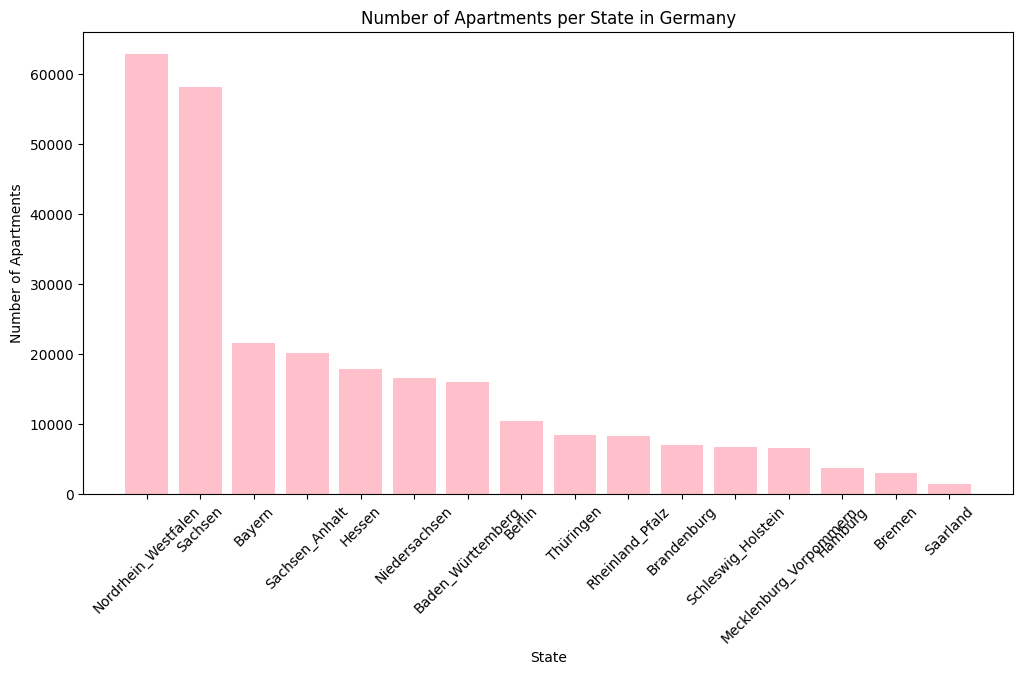

In [71]:
import matplotlib.pyplot as plt
df["regio2"].value_counts()
state_counts = df["regio1"].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(state_counts.index, state_counts.values,color="pink")
plt.title("Number of Apartments per State in Germany")
plt.xlabel("State")
plt.ylabel("Number of Apartments")
plt.xticks(rotation=45)
plt.show()

In [72]:
df["noRooms"].describe()

,noRooms
count,268762.000000
mean,2.640954
std,2.629819
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,999.990000


**General Question**

Based on all the above tasks and methods that you applied on the dataset, what can you say about the data?

* What information is the dataset trying to give you?

# This dataset is from Immoscout24, the biggest real estate platform in Germany. It was collected in 2018 and 2019. The dataset contains information about rental apartments such as rent, size, location, condition, heating type and number of rooms.

* Is the dataset complete? How would you define a data to be complete?

# The dataset is not complete because many missing values were found. 7 columns had above 50% missing values and had to be dropped. For the remaining columns, missing values were filled using the median for numerical columns (like totalRent) and the mode for categorical columns (like condition). Some data errors were also found, for example unrealistic living space values of 0 m² and 111,111 m².

* What are the general trends showing in the dataset?

# Leipzig city had the most apartment listings. The most common apartment condition was well_kept. Nordrhein-Westfalen had the most apartments among all German states. The results also showed some differences before and after data cleaning.